In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
health_df = pd.read_csv("../data/uds_data.csv")


health_df.head()

health_df.shape


(558553, 198)

In [3]:
print(health_df.columns)

Index(['no_show', 'age', 'GENDER', 'RACE', 'ETHNICITY', 'APPT_WEEKDAY',
       'APPT_DAY_PART', 'DURATION', 'BOOK_TO_APPT', 'APPT_SEQ',
       ...
       'r_SE_stt', 'r_COI_stt', 'c5_ED_met', 'c5_HE_met', 'c5_SE_met',
       'c5_COI_met', 'r_ED_met', 'r_HE_met', 'r_SE_met', 'r_COI_met'],
      dtype='object', length=198)


In [4]:
no_shows = ((health_df['no_show'] == "Yes")).sum()
shows = ((health_df['no_show'] == "No")).sum()

print(no_shows/(shows + no_shows))

0.12363374648421904


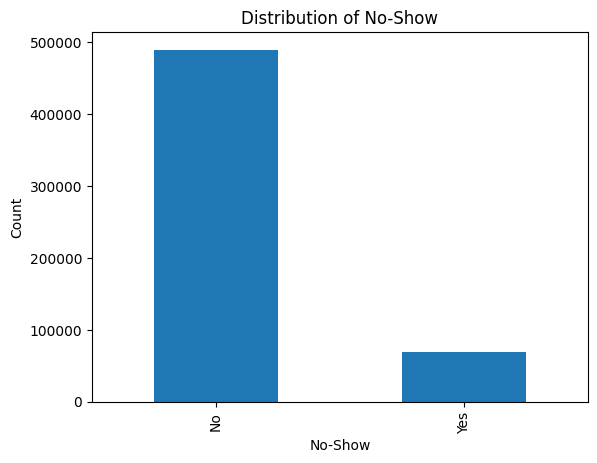

In [5]:
plt.figure()
health_df["no_show"].value_counts().plot(kind="bar")
plt.title("Distribution of No-Show")
plt.xlabel("No-Show")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

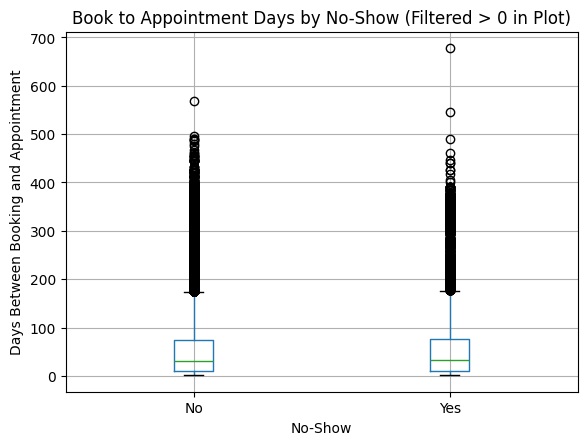

In [6]:
plt.figure()
#removing all negative days
filtered_data = health_df[health_df["BOOK_TO_APPT"] > 0]
filtered_data.boxplot(column="BOOK_TO_APPT", by="no_show")
plt.title("Book to Appointment Days by No-Show (Filtered > 0 in Plot)")
plt.suptitle("")
plt.xlabel("No-Show")
plt.ylabel("Days Between Booking and Appointment")
plt.show()

<Figure size 640x480 with 0 Axes>

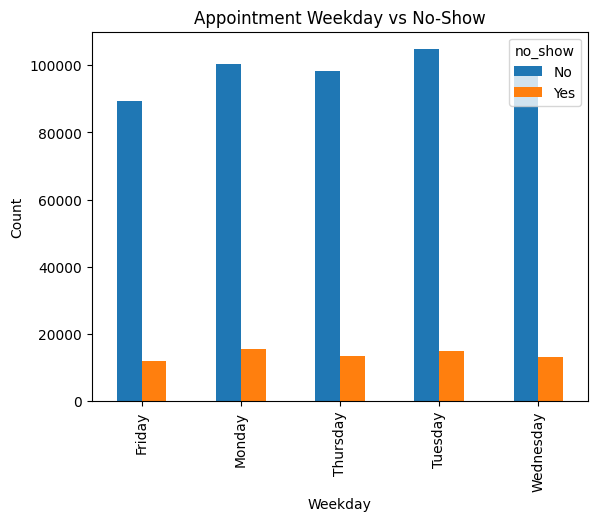

In [7]:
plt.figure()
pd.crosstab(health_df["APPT_WEEKDAY"], health_df["no_show"]).plot(kind="bar")
plt.title("Appointment Weekday vs No-Show")
plt.xlabel("Weekday")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

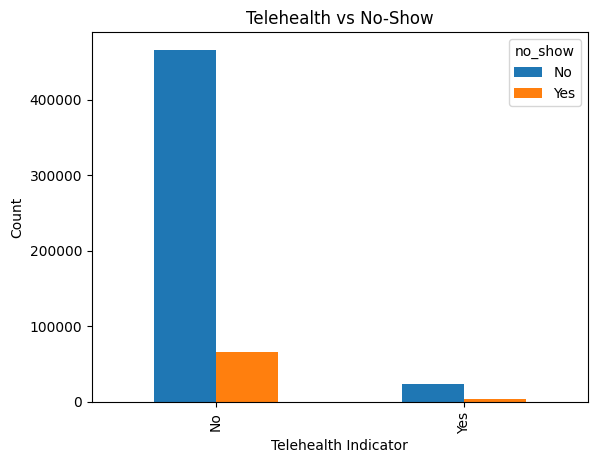

In [8]:
plt.figure()
pd.crosstab(health_df["TELEHEALTH_IND"], health_df["no_show"]).plot(kind="bar")
plt.title("Telehealth vs No-Show")
plt.xlabel("Telehealth Indicator")
plt.ylabel("Count")
plt.show()

In [9]:
# print(health_df['NOSHOWS_365'].describe())
print(health_df['RPL_THEMES'])

0         0.6235
1         0.7066
2         0.5082
3         0.9801
4         0.1569
           ...  
558548    0.1407
558549       NaN
558550    0.8076
558551    0.8355
558552    0.2342
Name: RPL_THEMES, Length: 558553, dtype: float64


C:\Users\anony\AppData\Local\Temp\ipykernel_56316\1843598542.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = health_df.groupby(['behavior_risk', 'svi_q'])['no_show'].mean().unstack()


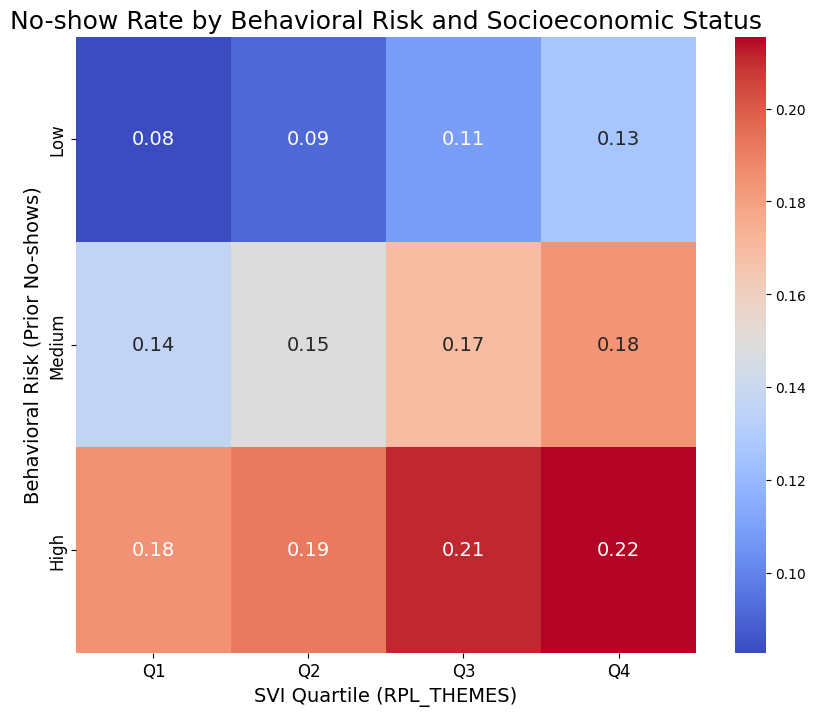

In [ ]:
import seaborn as sns
import matplotlib as pyplot

health_df['no_show'] = health_df['no_show'].map({'No': 0, 'Yes': 1})


# Behavioral risk bins
health_df['behavior_risk'] = pd.cut(health_df['NOSHOWS_365'],
                            bins=[-1, 0, 2, 100],
                            labels=['Low', 'Medium', 'High'])

# Socioeconomic quartiles (based on rank)
health_df['svi_q'] = pd.qcut(health_df['RPL_THEMES'], 4, labels=['Q1','Q2','Q3','Q4'])

# heatmap
heatmap_data = health_df.groupby(['behavior_risk', 'svi_q'])['no_show'].mean().unstack()

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 14}
)

plt.title(
    "No-show Rate by Behavioral Risk and Socioeconomic Status",
    fontsize=18
)

plt.ylabel(
    "Behavioral Risk (Prior No-shows)",
    fontsize=14
)

plt.xlabel(
    "SVI Quartile (RPL_THEMES)",
    fontsize=14
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

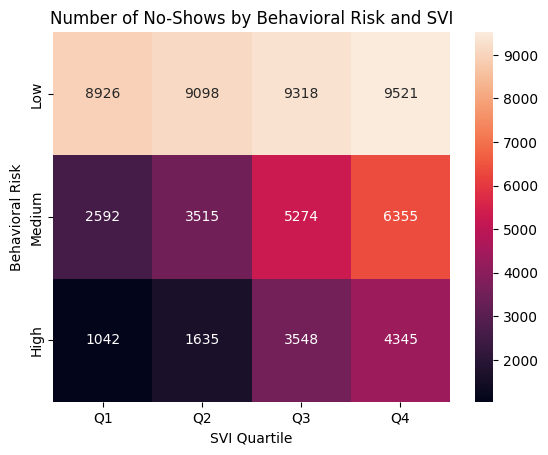

In [ ]:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html
# unstack

heatmap_counts = health_df[health_df['no_show'] == 1].groupby(['behavior_risk', 'svi_q'])['no_show'].count().unstack()

sns.heatmap(heatmap_counts, annot=True, fmt="d")
plt.title("Number of No-Shows by Behavioral Risk and SVI")
plt.ylabel("Behavioral Risk")
plt.xlabel("SVI Quartile")
plt.show()

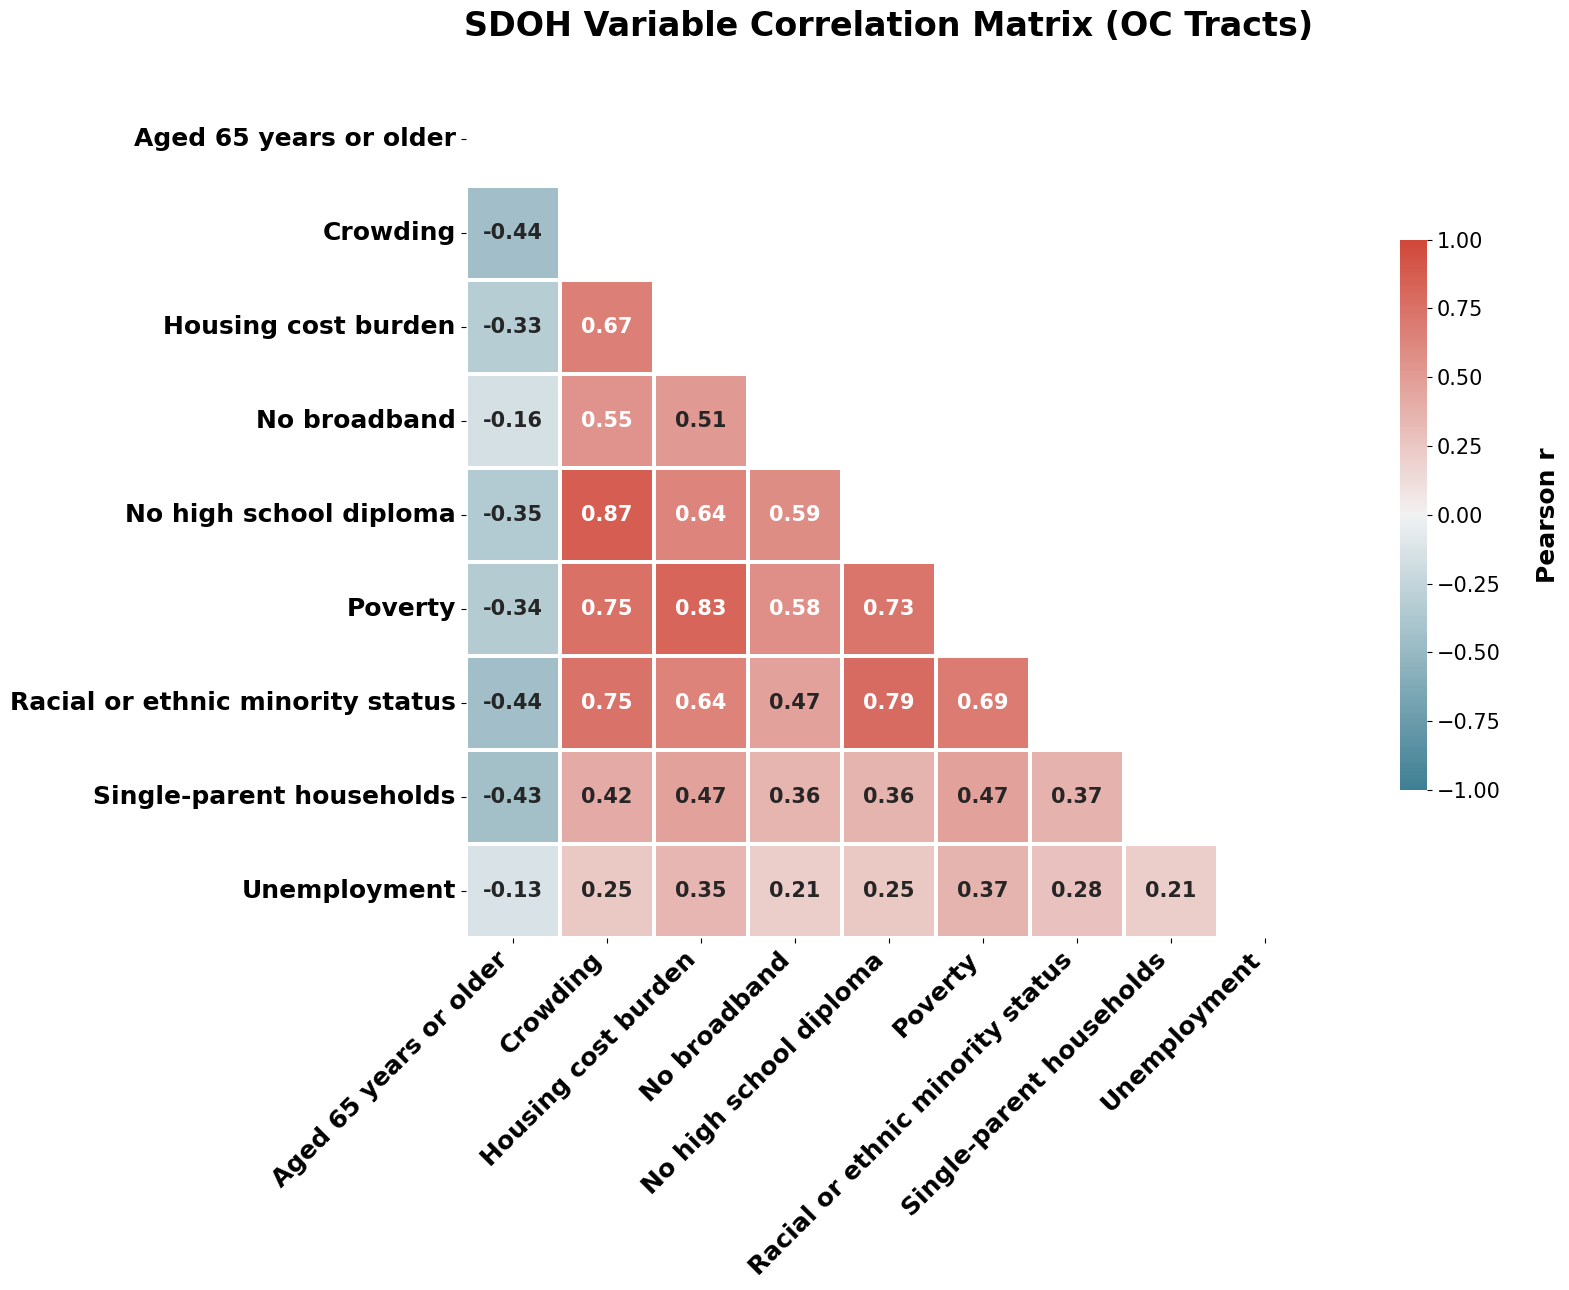

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

column_mapping = {
    "EP_AGE65": "Aged 65 years or older",
    "EP_CROWD": "Crowding",
    "EP_HBURD": "Housing cost burden",
    "EP_NOINT": "No broadband",          
    "EP_NOHSDP": "No high school diploma",
    "EP_POV150": "Poverty",               
    "EP_MINRTY": "Racial or ethnic minority status",
    "EP_SNGPNT": "Single-parent households",
    "EP_UNEMP": "Unemployment"
}

svi_cols = list(column_mapping.keys())
matrix_df = health_df[svi_cols].copy().rename(columns=column_mapping)

desired_order = [
    "Aged 65 years or older", "Crowding", "Housing cost burden", 
    "No broadband", "No high school diploma", "Poverty", 
    "Racial or ethnic minority status", "Single-parent households", "Unemployment"
]
matrix_df = matrix_df[desired_order]
matrix = matrix_df.corr(method='pearson', numeric_only=True)

# --- 4. Mask the upper triangle ---
mask = np.triu(np.ones_like(matrix, dtype=bool), k=0)
fig, ax = plt.subplots(figsize=(20, 13))
cmap = sns.diverging_palette(220, 15, as_cmap=True)

sns.heatmap(
    matrix, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    annot=True,              
    fmt=".2f",               
    square=True,             
    linewidths=1.5,          
    ax=ax,                    
    annot_kws={"size": 15, "weight": "bold"}, 
    cbar_kws={"shrink": 0.65}
)

plt.xticks(rotation=45, ha='right', fontsize=18, weight='bold')
plt.yticks(rotation=0, fontsize=18, weight='bold')
cbar = ax.collections[0].colorbar
if cbar is not None:
    cbar.set_label("Pearson r", fontsize=18, labelpad=25, weight='bold')
    cbar.ax.tick_params(labelsize=15)
# 6. Global Title Configuration
plt.title("SDOH Variable Correlation Matrix (OC Tracts)", fontsize=24, pad=40, weight='bold')
plt.tight_layout()
plt.show()